In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('OrderDetails_2026_03_15-2026_06_15.csv')
df.info()
df.head(10)
df.dropna()
df = df[df['Amount'] > 0]

<class 'pandas.DataFrame'>
RangeIndex: 3254 entries, 0 to 3253
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Opened           3254 non-null   str    
 1   # of Guests      3254 non-null   int64  
 2   Table            3084 non-null   str    
 3   Discount Amount  3254 non-null   float64
 4   Amount           3254 non-null   float64
 5   Tax              3254 non-null   float64
 6   Tip              3254 non-null   float64
 7   Gratuity         3254 non-null   float64
 8   Closed           3238 non-null   str    
dtypes: float64(5), int64(1), str(3)
memory usage: 228.9 KB


In [3]:
df['Amount'].sort_values(ascending=False)

1320    4704.00
1638    1672.00
2887    1378.64
3144    1258.00
3207    1130.00
         ...   
1739       8.50
1322       7.00
1316       4.00
1319       1.00
3044       0.01
Name: Amount, Length: 3088, dtype: float64

In [4]:
opened_dt = pd.to_datetime(df['Opened'], format='%m/%d/%y %I:%M %p')
closed_dt = pd.to_datetime(df['Closed'], format='%m/%d/%y %I:%M %p')

df.insert(0, 'Date', opened_dt.dt.strftime('%m/%d/%y'))
df['Duration'] = (closed_dt - opened_dt).dt.total_seconds() / 60  # minutes
df['Duration'].info()
df = df[df['Duration'] >= 15]

df['Opened'] = opened_dt.dt.strftime('%I:%M %p')
df['Closed'] = closed_dt.dt.strftime('%I:%M %p')

df.head(10)

<class 'pandas.Series'>
Index: 3088 entries, 0 to 3252
Series name: Duration
Non-Null Count  Dtype  
--------------  -----  
3088 non-null   float64
dtypes: float64(1)
memory usage: 48.2 KB


,Date,Opened,# of Guests,Table,Discount Amount,Amount,Tax,Tip,Gratuity,Closed,Duration
0,03/15/26,04:04 PM,6,BD1,0.0,335.0,30.58,20.00,67.0,07:05 PM,181.0
1,03/15/26,04:04 PM,4,O1,0.0,232.0,21.20,50.76,0.0,06:10 PM,126.0
2,03/15/26,04:31 PM,4,O4,5.2,416.8,38.03,0.00,0.0,08:15 PM,224.0
3,03/15/26,04:18 PM,2,B12,0.0,133.0,12.14,20.00,0.0,12:21 AM,483.0
4,03/15/26,04:42 PM,2,O7,0.0,74.0,6.76,15.00,0.0,06:35 PM,113.0
5,03/15/26,04:58 PM,2,O6,0.0,144.0,13.11,0.00,0.0,08:01 PM,183.0
7,03/15/26,05:51 PM,4,O10,0.0,198.0,18.07,40.00,0.0,07:54 PM,123.0
8,03/15/26,06:56 PM,5,O1,0.0,122.0,11.15,15.00,0.0,08:46 PM,110.0
9,03/15/26,06:57 PM,7,BD1,0.0,89.0,8.11,0.00,0.0,08:03 PM,66.0
10,03/15/26,07:14 PM,2,B12,0.0,128.0,11.67,0.00,0.0,12:19 AM,305.0


In [ ]:
df['Table'].split()

<StringArray>
['BD1',  'O1',  'O4', 'B12',  'O7',  'O6', 'O10',  'B6',  'B9',  'O3',  'B1',
 'B11',   nan, 'BD5',  'B3',  'B8',  'B5',  'B7', 'B14', 'BD2', 'B10',  'O8',
  'O9',  'E2',  'O5',  'E1',  'E3',  'B4',  'O2', 'BD3',  'B2', 'B13']
Length: 32, dtype: str

# Value per Person per 15 Minutes

In [6]:
df['VPCPM'] = (df['Amount'] / df['# of Guests']) / (df['Duration'] / 15)
df['VPCPM'].head(10)
df['Mean VPCPM'] = df['# of Guests'].map(df.groupby('# of Guests')['VPCPM'].mean()) # understand why this works
df.head(20).sort_values(by = 'VPCPM', ascending = False)

,Date,Opened,# of Guests,Table,Discount Amount,Amount,Tax,Tip,Gratuity,Closed,Duration,VPCPM,Mean VPCPM
11,03/15/26,07:15 PM,1,B6,0.0,244.0,22.28,40.00,0.0,12:21 AM,306.0,11.960784,8.857137
17,03/15/26,09:06 PM,2,O6,0.0,90.0,8.23,41.77,0.0,10:09 PM,63.0,10.714286,5.733103
15,03/15/26,08:43 PM,2,O3,0.0,146.0,13.35,41.65,0.0,10:54 PM,131.0,8.358779,5.733103
21,03/15/26,10:44 PM,2,B11,0.0,97.0,8.84,30.00,0.0,12:20 AM,96.0,7.578125,5.733103
2,03/15/26,04:31 PM,4,O4,5.2,416.8,38.03,0.00,0.0,08:15 PM,224.0,6.977679,4.901690
1,03/15/26,04:04 PM,4,O1,0.0,232.0,21.20,50.76,0.0,06:10 PM,126.0,6.904762,4.901690
18,03/15/26,09:42 PM,4,O10,0.0,204.0,18.63,44.88,0.0,11:38 PM,116.0,6.594828,4.901690
7,03/15/26,05:51 PM,4,O10,0.0,198.0,18.07,40.00,0.0,07:54 PM,123.0,6.036585,4.901690
5,03/15/26,04:58 PM,2,O6,0.0,144.0,13.11,0.00,0.0,08:01 PM,183.0,5.901639,5.733103
13,03/15/26,08:34 PM,4,O1,0.0,270.0,24.66,41.00,0.0,11:30 PM,176.0,5.752841,4.901690


In [7]:
# df.groupby('# of Guests')['VPCPM'].agg(['mean', 'count', 'min', 'max'])
# # df[df['# of Guests'] == 1][['Amount', 'Duration', 'VPCPM']]
df.groupby('# of Guests')['VPCPM'].mean().reset_index().rename(columns={'VPCPM': 'Mean VPCPM'})

,# of Guests,Mean VPCPM
0,1,8.857137
1,2,5.733103
2,3,4.430396
3,4,4.901690
4,5,4.571585
5,6,4.384803
6,7,3.544131
7,8,4.297918
8,9,3.873501
9,10,4.928839


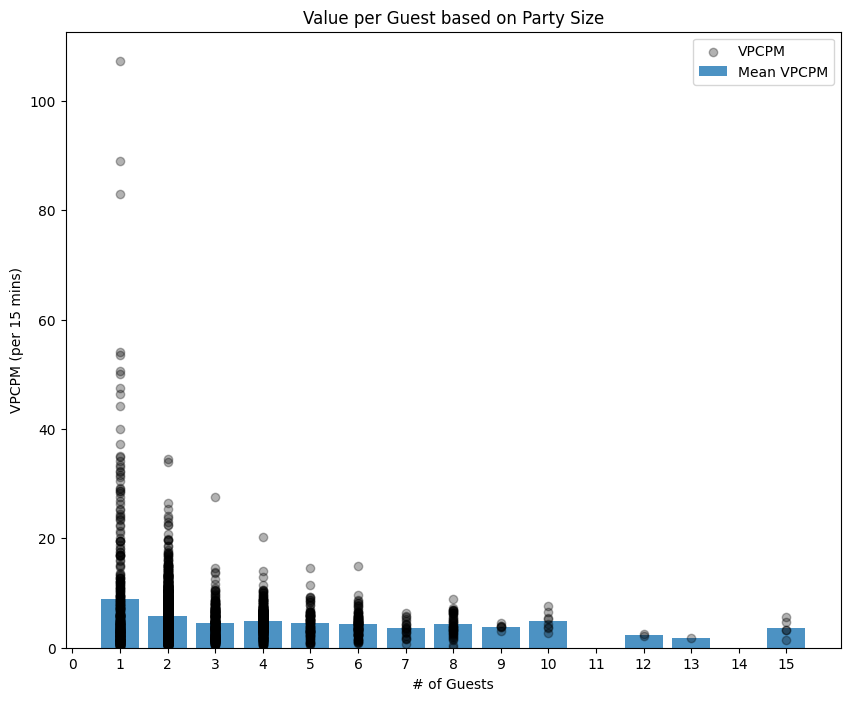

In [8]:
import matplotlib.pyplot as plt

mean_vpcpm = df.groupby('# of Guests')['VPCPM'].mean()
fig, ax = plt.subplots(figsize = (10,8))

ax.bar(mean_vpcpm.index, mean_vpcpm, alpha = 0.8)
ax.scatter(df['# of Guests'], df['VPCPM'], alpha=0.3, color='black')

plt.title('Value per Guest based on Party Size')
plt.xlabel('# of Guests')
plt.ylabel('VPCPM (per 15 mins)')
plt.legend(['VPCPM', 'Mean VPCPM'],loc = 'best')
plt.xticks(range(0,16)); # semi-colon prevents text output 

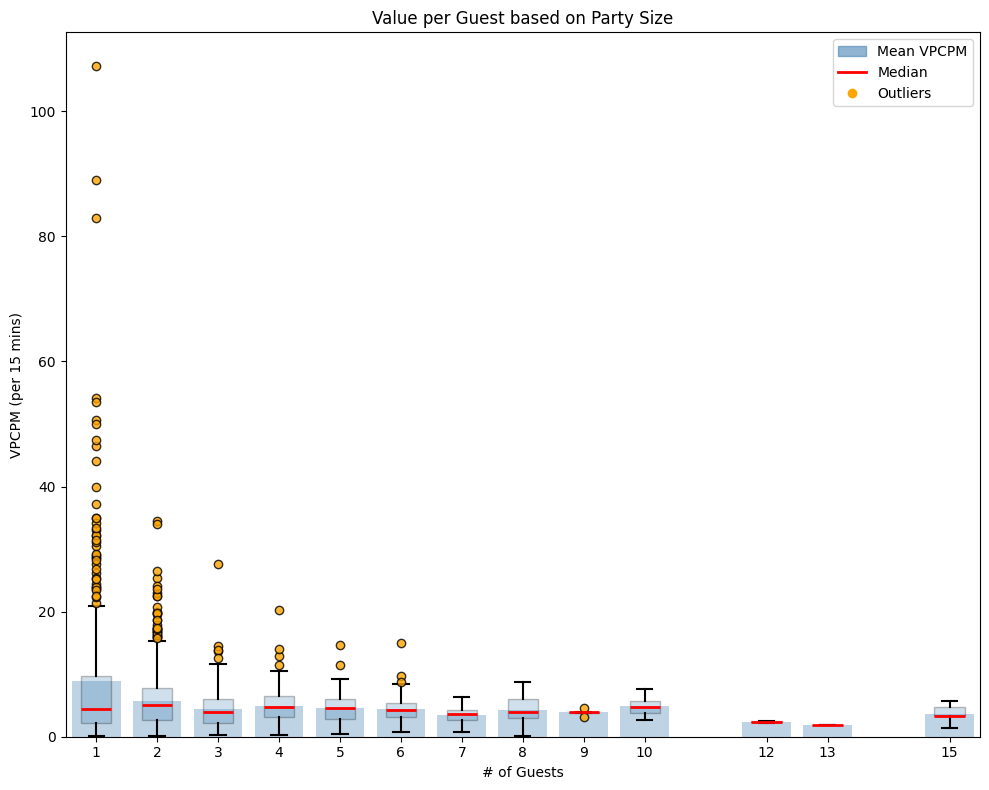

In [9]:
import matplotlib.pyplot as plt

mean_vpcpm = df.groupby('# of Guests')['VPCPM'].mean()
guest_sizes = sorted(df['# of Guests'].unique())
groups = [df[df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(mean_vpcpm.index, mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)

ax.boxplot(groups, positions=guest_sizes, widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.25),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5),
           zorder=2)

ax.set_xticks(guest_sizes)
ax.set_xlabel('# of Guests')
ax.set_ylabel('VPCPM (per 15 mins)')
ax.set_title('Value per Guest based on Party Size')

handles = [
    plt.Rectangle((0, 0), 1, 1, color='steelblue', alpha=0.6),
    plt.Line2D([0], [0], color='red', linewidth=2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8),
]
ax.legend(handles, ['Mean VPCPM', 'Median', 'Outliers'], loc='best')
plt.tight_layout()
plt.show()

## Who Spends More Per Hour? — Descriptive Analysis by Party Size